In [91]:
import sys, os
from pathlib import Path
os.chdir("/Users/samstephenson/Downloads/capy-bara")   # for pipeline (2 levels up = capy-bara/)     # for pipeline (2 levels up = capy-bara/)
import capy_core.metrics as metrics
import matplotlib.pyplot as plt
import numpy as np
import random
random.seed(42)
import pathlib
import capy_core.metrics as metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import gerrychain
from collections import deque
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.sparse.csgraph import shortest_path
import capy_core.metrics as metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import gerrychain.grid
import random
from collections import deque
from matplotlib.colors import ListedColormap
random.seed(42)

In [92]:
def draw_grid_as_checkerboard(graph, id, rho, ax=None, title=""):
    """
    Render a gerrychain Grid as a two-color image showing x_pop vs y_pop nodes.

    Parameters
    ----------
    graph : gerrychain.grid.Grid
        GerryChain wrapper; graph.graph is the underlying nx.Graph.
    id : str
        Identifier used in the output filename.
    rho : float
        Global rho value used in the output filename.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on; a new figure is created if None.
    title : str, optional
        Unused; reserved for future labeling.

    Returns
    -------
    matplotlib.axes.Axes
    """

    G = graph.graph
    nodes = list(G.nodes())
    # gerrychain grid nodes are (col, row) tuples
    cols = [n[0] for n in nodes]
    rows = [n[1] for n in nodes]
    width  = max(cols) + 1
    height = max(rows) + 1

    grid = np.zeros((height, width))
    for n in nodes:
        # 1 if x_pop > 0, 0 if y_pop > 0
        grid[n[1], n[0]] = 1 if G.nodes[n]["x_pop"] > 0 else 0

    if ax is None:
        _, ax = plt.subplots()
    cmap = ListedColormap(["#FFA812", "#006B3C"])
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, origin="lower", interpolation="nearest")

    ax.axis("off")
    base_file_stem = f"figures/idealized_grids/fig-5_{id}_grid_visualization_rho={rho}"
    file_stem = base_file_stem.replace('.', 'p')
    plt.savefig(file_stem, dpi=300, bbox_inches="tight")
    return ax

In [93]:
def populate_cluster_random(start_node, graph, target_x_pop, rng):
    """
    Assigns x_pop via random cluster growth expansion from a seed node until the total x_pop reaches target_x_pop, then sets y_pop as the remainder for every node.
    Parameters:
        start_node: int
            The seed node from which random cluster growth expansion begins
        graph: nx.Graph
            County adjacency graph with node attribute TOTPOP; modified in place
        target_x_pop: float
            The total x_pop at which random cluster growth stops adding nodes to the cluster
        rng: random.Random
            Local RNG instance passed through to each populate_cluster_random call
    Returns:
        graph: nx.Graph
            The modified graph with x_pop and y_pop set on every node
        real_rho: float
            The actual achieved global group fraction, which may exceed the target due to discrete node assignments
    """
    
    queue = deque([start_node])

    visited = set()
    x_pop_sum = 0

    while queue and x_pop_sum < target_x_pop:
        queue = list(queue)
        rng.shuffle(queue)
        queue = deque(queue)
        node = queue.popleft()

        if node in visited or graph.nodes[node]["x_pop"] > 0:
            visited.add(node)
            continue
        visited.add(node)

        # assign values
        graph.nodes[node]["x_pop"] = graph.nodes[node]["TOTPOP"]
        graph.nodes[node]["y_pop"] = 0

        x_pop_sum += graph.nodes[node]["TOTPOP"]

        # add neighbors (randomized expansion)
        neighbors = list(graph.neighbors(node))
        rng.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited:
                queue.append(nbr)


    for node in graph.nodes():
        if graph.nodes[node]["x_pop"] == 0:
            graph.nodes[node]["y_pop"] = graph.nodes[node]["TOTPOP"]

    real_rho = metrics.property_sum(graph, "x_pop")/metrics.property_sum(graph, "TOTPOP")
    
    return graph, real_rho

def generate_kclust_grid(num_columns, num_rows, target_rho, node_pop, num_seeds, method = "bfs", blur = True, max_retries = 50):
    """
    Create an n×m gerrychain Grid with k contiguous x_pop clusters.

    Seeds are chosen from unoccupied nodes at the start of each cluster's
    expansion. All remaining nodes receive y_pop=node_pop.

    Parameters
    ----------
    num_columns, num_rows : int
        Grid dimensions (columns × rows).
    target_rho : float
        Target global fraction of x_pop, split evenly across k clusters.
        The realized rho returned may differ due to integer node counts.
    node_pop : int or float
        Population per node.
    k : int
        Number of clusters.
    method : {"bfs", "random"}
        Cluster expansion strategy.
    blur : bool
        Reserved for future use; currently has no effect.

    Returns
    -------
    tuple of (gerrychain.grid.Grid, float, int)
        The populated grid, the realized global rho, and the number of connected
        x_pop components (may exceed k if clusters merge or split).
    """
    G = gerrychain.grid.Grid((num_columns, num_rows))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["x_pop"] = 0
        G.graph.nodes[node]["y_pop"] = 0

    target_nodes = int((target_rho * num_columns * num_rows) / num_seeds)

    for i in range(num_seeds):
        y_nodes = [node for node in G.graph.nodes() if G.graph.nodes[node]["x_pop"] == 0]
        seed = random.choice(y_nodes)
        if method == "bfs":
            G = populate_cluster_bfs(seed, G, node_pop, target_nodes*node_pop)
        elif method == "random":
            G = populate_cluster_random(seed, G, node_pop, target_nodes*node_pop)

    for node in G.graph.nodes():
        if G.graph.nodes[node]["x_pop"] == 0:
            G.graph.nodes[node]["y_pop"] = node_pop
    
    real_rho = (metrics.property_sum(G.graph, "x_pop") / 
                (metrics.property_sum(G.graph, "x_pop") + 
                metrics.property_sum(G.graph, "y_pop")))
    
    x_nodes = [
        node for node in G.graph.nodes()
        if G.graph.nodes[node]["x_pop"] > 0
        ]

    H = G.graph.subgraph(x_nodes)

    components = nx.number_connected_components(H)


    return (G, real_rho, components)

def populate_cluster_bfs(start_node, graph, node_pop, target_x_pop):
    """
    Fill a contiguous cluster of x_pop nodes via BFS from start_node.

    Expands outward in BFS order (neighbors shuffled for randomness) until the
    cumulative x_pop reaches target_x_pop. Skips nodes already assigned x_pop > 0.

    Parameters
    ----------
    start_node : tuple
        (col, row) seed node for the cluster.
    graph : gerrychain.grid.Grid
    node_pop : int or float
        Population assigned to each node in the cluster (x_pop=node_pop, y_pop=0).
    target_x_pop : float
        Target total x_pop for the cluster.

    Returns
    -------
    gerrychain.grid.Grid
    """

    # queue for BFS
    queue = deque([start_node])

    visited = set()
    x_pop_sum = 0

    while queue and x_pop_sum < target_x_pop:
        node = queue.popleft()

        if node in visited or graph.graph.nodes[node]["x_pop"] > 0:
            visited.add(node)
            continue
        visited.add(node)

        # assign values
        graph.graph.nodes[node]["x_pop"] = node_pop
        graph.graph.nodes[node]["y_pop"] = 0

        x_pop_sum += node_pop

        # add neighbors (randomized expansion)
        neighbors = list(graph.graph.neighbors(node))
        random.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited:
                queue.append(nbr)
    return graph


In [94]:
import scipy
def moran(graph: gerrychain.Graph, x_col: str, tot_col: str, Weights: scipy.sparse.csr_matrix) -> float:
    """
    Calculates Moran's I for nodes' shares of group x using an arbitrary weights matrix.
    Moran's I is defined by $I(v;W): = \frac{n}{w}(\frac{x^TWx}{x^Tx})$ where W is the weights matrix,
    n is the number of edges, x is a vector containing each node's count of the x population, and 
    $w := \sum_{i,j} \lvert W_{ij} \rvert$.


    Parameters:
        graph: gerrychain.Graph or networkx.Graph
            The graph of interest
        x_col: string
            the column name for population group x
        tot_col: string
            the column name for the total population group
        W: scipy.sparse.csr_matrix
            the weights matrix for the Moran's I calculation

    Returns:
        float:
            the graph's Moran's I for group x.
    """
    try:
        shares = np.array([
            graph.nodes[node][x_col] / graph.nodes[node][tot_col]
            for node in graph.nodes()
            ])
    except ZeroDivisionError:
        raise ValueError("Division by Zero Error: calculating Moran's I requires that all nodes have a non-zero total population.")

    shares -= shares.mean()

    xvec = scipy.sparse.csr_matrix(shares).T

    denominator = (xvec.T @ xvec)[0, 0]
    if denominator == 0:
        raise ZeroDivisionError(
            "Moran's I is undefined when all node shares are identical"
        )

    numerator = (xvec.T @ Weights @ xvec)[0, 0]
    w = abs(Weights).sum()
    moran = (len(graph) / w) * numerator / denominator

    return moran

def build_higher_order_adj_matrix(graph, max_adjacency_order, damping_factor, include_self_loops = True):
    """
    """
    csg = nx.to_scipy_sparse_array(nx.Graph(graph), format='csr') #changing to csr format to run shortest_path
    dist_matrix = shortest_path(csg, unweighted = True) #nxn array with graph distances in the entries
    size = len(dist_matrix)
    adj_matrix = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if dist_matrix[i, j] == 0:
                continue
            elif dist_matrix[i,j] > max_adjacency_order:
                adj_matrix[i, j] = 0
            else: 
                adj_matrix[i,j] = damping_factor ** (dist_matrix[i,j] -1)
    if include_self_loops == True:
        adj_matrix = adj_matrix + np.eye(size)
    return adj_matrix

In [95]:
def generate_isol_grid(num_columns, num_rows, rho, node_pop):
    """
    Create an n×m gerrychain Grid with maximally isolated (scattered) x_pop nodes.

    Starts from a checkerboard at rho=0.5, then randomly converts x_pop nodes to
    y_pop nodes until the target rho is reached.

    Parameters
    ----------
    num_columns, num_rows : int
        Grid dimensions (columns × rows).
    rho : float
        Target global fraction of x_pop (must be <= 0.5).
    node_pop : int or float
        Population per node.

    Returns
    -------
    gerrychain.grid.Grid
    """
    
    G = generate_ch_grid(num_columns, num_rows, .5, node_pop)
    nodes = list(G.graph.nodes)
    random.shuffle(nodes)
    current_x_pop = num_columns * num_rows * node_pop * .5
    target_x_pop = num_columns * num_rows * node_pop * rho

    for node in nodes:
        if current_x_pop <= target_x_pop:
            break
        if G.graph.nodes[node]["y_pop"] == 0:
            G.graph.nodes[node]["x_pop"] = 0
            G.graph.nodes[node]["y_pop"] = node_pop
            current_x_pop = current_x_pop - node_pop
    real_rho = (metrics.property_sum(G.graph, "x_pop") / 
                (metrics.property_sum(G.graph, "x_pop") + 
                 metrics.property_sum(G.graph, "y_pop")))
    return (G, real_rho)

def generate_ch_grid(num_columns: int, num_rows: int, rho, node_pop, eps = False):
    """
    Create and populate an n×m gerrychain Grid in a checkerboard pattern.

    Parameters
    ----------
    num_columns, num_rows : int
        Grid dimensions (columns × rows).
    rho : float
        Target global fraction of x_pop.
    node_pop : int or float
        Base population per node.
    eps : bool
        If True, add random noise to population assignments.

    Returns
    -------
    gerrychain.grid.Grid
    """

    G = gerrychain.grid.Grid((num_columns, num_rows))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["sum"] = node[0] + node[1]
    if eps == True:
        G = populate_ch_grid(G, rho, node_pop, eps = True)
    else:
        G = populate_ch_grid(G, rho, node_pop, eps = False)
    return G

def populate_ch_grid(graph, rho, node_pop, eps): #give graph x and y pop'scripts
    """
    Assign checkerboard x_pop/y_pop populations to an existing gerrychain Grid.

    Nodes where (x_coordinate + y_coordinate) is even receive only y_pop; nodes where (x + y) is odd
    receive x_pop = 2*node_pop*rho and y_pop = node_pop*(1 - 2*rho). With eps=True, small
    uniform random noise is added to each assignment.

    Parameters
    ----------
    graph : gerrychain.grid.Grid
        Grid whose nodes already have "x" and "y" coordinate attributes.
    rho : float
        Target global fraction of x_pop.
    node_pop : int or float
        Base population per node.
    eps : bool
        If True, add random noise to population assignments.

    Returns
    -------
    gerrychain.grid.Grid
    """

    for node in graph.graph.nodes:
        if graph.graph.nodes[node]["sum"] % 2 == 0:
            if eps == True:
                e_x = random.randint(-5, 5)
                e_y = random.randint(-5, 5)
                graph.graph.nodes[node]["x_pop"] = 0
                graph.graph.nodes[node]["y_pop"] = node_pop + e_y
            else:
                graph.graph.nodes[node]["x_pop"] = 0
                graph.graph.nodes[node]["y_pop"] = node_pop
        else:
            if eps == True:
                e_x = random.uniform(-5, 5)
                e_y = random.uniform(-5, 5)
                graph.graph.nodes[node]["x_pop"] = 2 * node_pop * rho + 2 + rho * e_x
                graph.graph.nodes[node]["y_pop"] = node_pop * (1 - 2* rho) + (1 - 2* rho) *e_y
            else:
                graph.graph.nodes[node]["x_pop"] = 2 * node_pop * rho
                graph.graph.nodes[node]["y_pop"] = node_pop * (1 - 2* rho) 
    return graph

In [96]:
def get_moran_radius_profile(graph, max_radius, damping_factor, x_col, tot_col, include_self_loops = True):
    """
    """
    morans = []
    if include_self_loops == True:
        for i in range(max_radius):
            adj_matrix = build_higher_order_adj_matrix(graph, i, damping_factor, include_self_loops=include_self_loops) 
            morans.append(moran(graph, x_col, tot_col, adj_matrix))
    else:
        for i in range(max_radius)[1:]:
            adj_matrix = build_higher_order_adj_matrix(graph, i, damping_factor, include_self_loops=include_self_loops) 
            morans.append(moran(graph, x_col, tot_col, adj_matrix))
    return morans

In [97]:
def build_grid_medium(rows, cols, rho, cell_pop=1000, rng=42):
    """
    Uniform random assignment: exactly half the cells get BLUE=cell_pop, the
    other half BLUE=0, in a shuffled order. No spatial correlation = Moran's I
    near 0 = medium clustering.
    """
    rng = random.Random(rng)
    G = generate_ch_grid(cols, rows, .5, cell_pop)
    for node in G.graph.nodes():
        G.graph.nodes[node]["x_pop"] = 0
        G.graph.nodes[node]["y_pop"] = 0
    nodelist = [node for node in G.graph.nodes()]
    rng.shuffle(nodelist)
    tot_x_pop = 0
    target_x_pop = rows * cols * cell_pop * rho
    for node in nodelist:
        if tot_x_pop < target_x_pop:
            G.graph.nodes[node]["x_pop"] = cell_pop
            G.graph.nodes[node]["y_pop"] = 0
            tot_x_pop += cell_pop
        else:
            break
    for node in nodelist:
        if G.graph.nodes[node]["x_pop"] == 0:
            G.graph.nodes[node]["x_pop"] = 0
            G.graph.nodes[node]["y_pop"] = cell_pop
    real_rho = (metrics.property_sum(G.graph, "x_pop") / 
            (metrics.property_sum(G.graph, "x_pop") + 
            metrics.property_sum(G.graph, "y_pop")))
    return G, real_rho


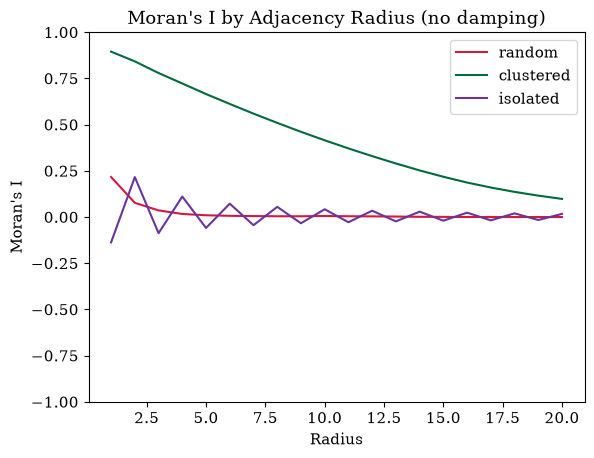

In [98]:
g, real_rho, components = generate_kclust_grid(40, 40, .3, 1000, 4)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_clust = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")

g, real_rho = generate_isol_grid(40, 40, 0.3, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_isol = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")

g, real_rho = build_grid_medium(40, 40, 0.3, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_random = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")


plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(21)[1:]
ax.plot(radii, morans_random[1:],   color="#d11a42",   label="random")
ax.plot(radii, morans_clust[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, morans_isol[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (no damping)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")
fig.savefig("figures/iowa_prototypes/moran_by_adj", dpi = 300, bbox_inches="tight")

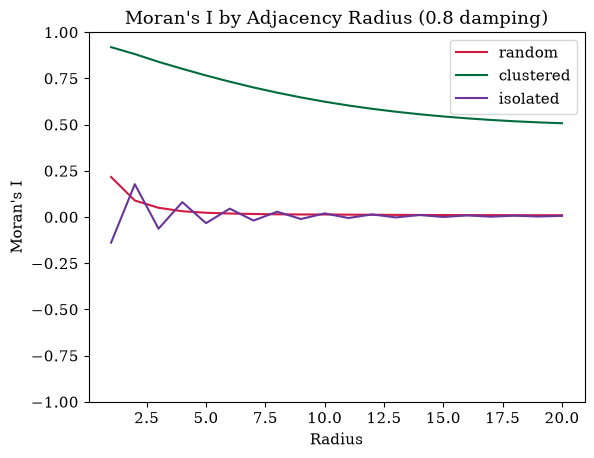

In [99]:
g, real_rho, components = generate_kclust_grid(40, 40, .3, 1000, 4)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_clust = get_moran_radius_profile(g.graph, 21, 0.8, "x_pop", "total_pop")

g, real_rho = generate_isol_grid(40, 40, 0.3, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_isol = get_moran_radius_profile(g.graph, 21, 0.8, "x_pop", "total_pop")

g, real_rho = build_grid_medium(40, 40, 0.3, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_random = get_moran_radius_profile(g.graph, 21, 0.8, "x_pop", "total_pop")


plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(21)[1:]
ax.plot(radii, morans_random[1:],   color="#d11a42",   label="random")
ax.plot(radii, morans_clust[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, morans_isol[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (0.8 damping)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")
fig.savefig("figures/iowa_prototypes/moran_by_adj_0p8_damping", dpi = 300, bbox_inches="tight")

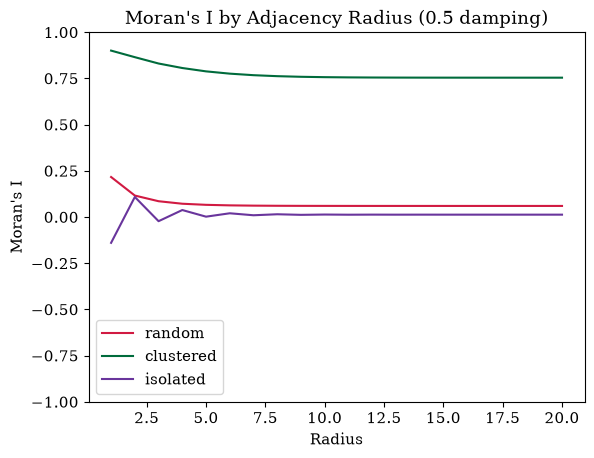

In [100]:
g, real_rho, components = generate_kclust_grid(40, 40, .3, 1000, 4)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_clust = get_moran_radius_profile(g.graph, 21, 0.5, "x_pop", "total_pop")

g, real_rho = generate_isol_grid(40, 40, 0.3, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_isol = get_moran_radius_profile(g.graph, 21, 0.5, "x_pop", "total_pop")

g, real_rho = build_grid_medium(40, 40, 0.3, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_random = get_moran_radius_profile(g.graph, 21, 0.5, "x_pop", "total_pop")


plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(21)[1:]
ax.plot(radii, morans_random[1:],   color="#d11a42",   label="random")
ax.plot(radii, morans_clust[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, morans_isol[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (0.5 damping)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")
fig.savefig("figures/iowa_prototypes/moran_by_adj_0p5_damping", dpi = 300, bbox_inches="tight")

KeyboardInterrupt: 

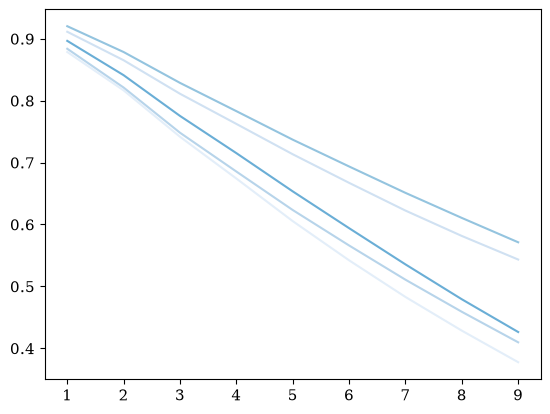

In [101]:
TARGET_RHO = 0.3
max_radius = 10
max_num_clusters = 10
fig, ax = plt.subplots()
radii = range(max_radius)[1:]
graph = gerrychain.Graph.from_json("data/experiment_specific/ia_files/ia_counties_2020.json")
real_rhos = []
for i in range(max_num_clusters + 1)[1:]:
    rng = random.Random(i)
    g, real_rho, components = generate_kclust_grid(40, 40, .3, 1000, 4)
    for node in g.graph.nodes():
        g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
    real_rhos.append(real_rho)
    morans = get_moran_radius_profile(g.graph, max_radius, 1, "x_pop", "total_pop")
    ax.plot(radii, morans[1:], color=plt.cm.Blues(i / max_num_clusters)
,   label=f"{i} cluster starting points")
ax.set_ylim(-1, 1)
ax.legend(fontsize=8)
ax.set_title("Moran's I by Adjacency Radius (no damping)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")

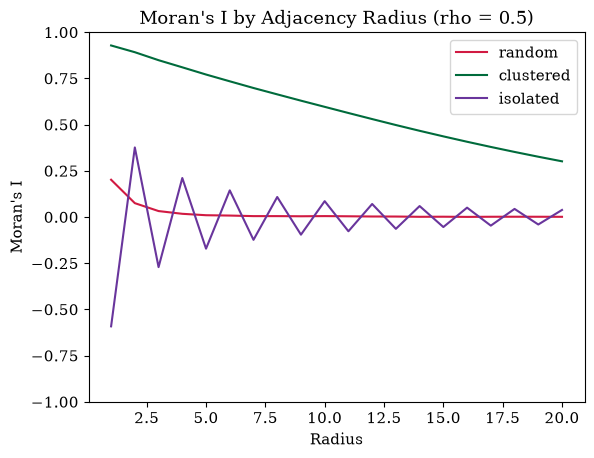

In [ ]:
g, real_rho, components = generate_kclust_grid(40, 40, .5, 1000, 4)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_clust = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")

g, real_rho = generate_isol_grid(40, 40, 0.5, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_isol = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")

g, real_rho = build_grid_medium(40, 40, 0.5, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_random = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")


plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(21)[1:]
ax.plot(radii, morans_random[1:],   color="#d11a42",   label="random")
ax.plot(radii, morans_clust[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, morans_isol[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (rho = 0.5)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")
fig.savefig("figures/iowa_prototypes/moran_by_adj_0p5_rho", dpi = 300, bbox_inches="tight")

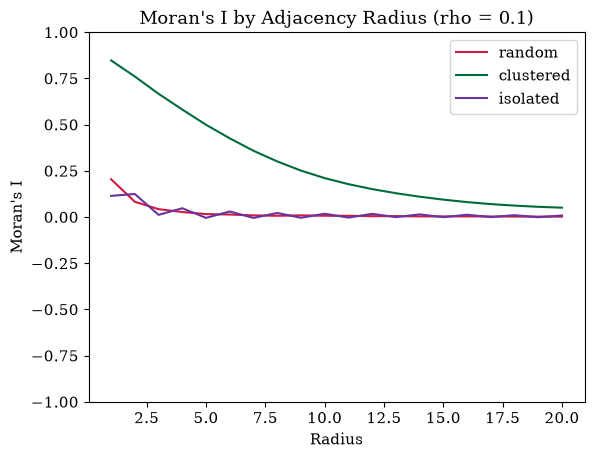

In [ ]:
g, real_rho, components = generate_kclust_grid(40, 40, .1, 1000, 4)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_clust = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")

g, real_rho = generate_isol_grid(40, 40, 0.1, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_isol = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")

g, real_rho = build_grid_medium(40, 40, 0.1, 1000)
for node in g.graph.nodes():
    g.graph.nodes[node]["total_pop"] = g.graph.nodes[node]["x_pop"] + g.graph.nodes[node]["y_pop"]
morans_random = get_moran_radius_profile(g.graph, 21, 1, "x_pop", "total_pop")


plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(21)[1:]
ax.plot(radii, morans_random[1:],   color="#d11a42",   label="random")
ax.plot(radii, morans_clust[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, morans_isol[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (rho = 0.1)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")
fig.savefig("figures/iowa_prototypes/moran_by_adj_0p1_rho", dpi = 300, bbox_inches="tight")

<Axes: >

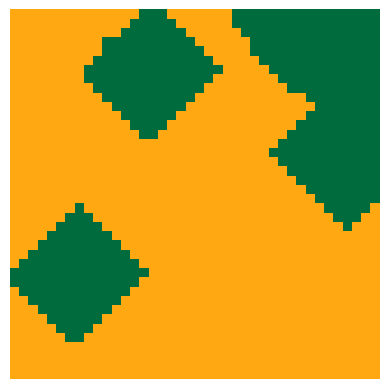

In [103]:
g, real_rho, components = generate_kclust_grid(40, 40, .3, 1000, 4)
draw_grid_as_checkerboard(g, "clustered", 0.3)

<Axes: >

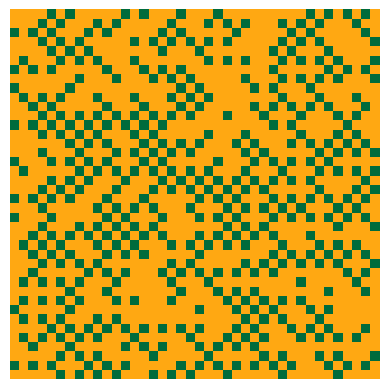

In [104]:
g, real_rho = generate_isol_grid(40, 40, 0.3, 1000)
draw_grid_as_checkerboard(g, "isol", 0.3)

<Axes: >

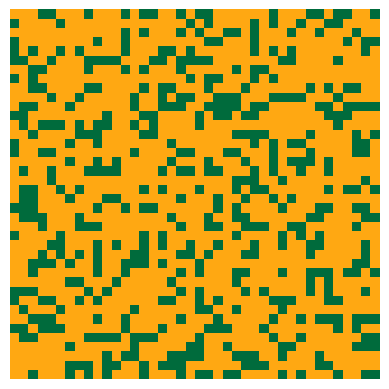

In [105]:
g, real_rho = build_grid_medium(40, 40, 0.3, 1000)
draw_grid_as_checkerboard(g, "random", 0.3)